In [1]:
from mfl_rom.benchmarks.synthetic import (
    generate_latent_trajectory,
    generate_mf_trajectory,
    sample_ic,
)

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from matplotlib.animation import FuncAnimation
from IPython.display import HTML



# Toy Problem

This notebook visualizes the trajectories generated by a synthetic benchmark used to test the methodology in a controlled setting.

The trajectories are generated from a two-dimensional latent ODE of the form
$$
\dot{\mathbf z}(t)=
\begin{bmatrix}
\alpha z_1 - \omega z_2 - \beta (z_1^2+z_2^2) z_1 \\
\omega z_1 + \alpha z_2 - \beta (z_1^2+z_2^2) z_2
\end{bmatrix},
\qquad
\mathbf z(0)=\mathbf z_0 .
$$

The high-fidelity trajectories are then obtained through the scalar lifting
$$
u_{\mathrm{HF}}(x,y;t)
=
z_1(t)\sin(\pi x)\sin(\pi y)
+
z_2(t)\sin(2\pi x)\sin(2\pi y).
$$

The low-fidelity trajectories are obtained by observing the same underlying field on a coarser grid and adding a mild smooth bias and noise:
$$
u_{\mathrm{LF}}(x,y;t)
=
u_{\mathrm{HF}}(x,y;t)
+
b\,\cos(\pi x)\cos(\pi y)
+
\sigma \,\xi(x,y,t).
$$


### Latent trajectories

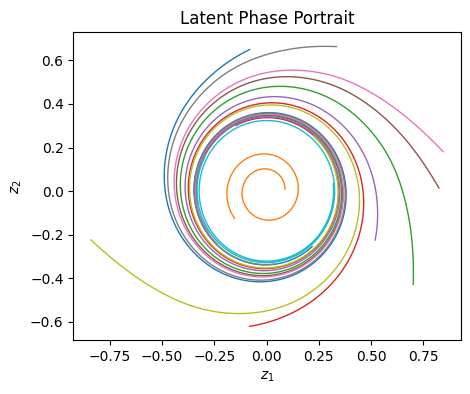

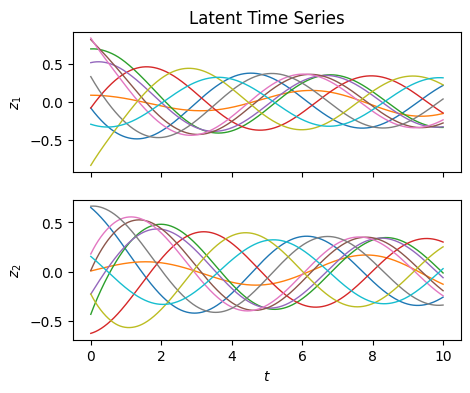

In [6]:
n_trajs = 10
rng = np.random.default_rng(0)
time = np.linspace(0.0, 10.0, 1000)

ics = [sample_ic(rng=rng) for _ in range(n_trajs)]
trajs = [generate_latent_trajectory(ic, time) for ic in ics]

plt.figure(figsize=(5,4))
for traj in trajs:
    plt.plot(traj[:, 0], traj[:, 1], linewidth=1)
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.title("Latent Phase Portrait")
plt.show()

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(5,4))

for traj in trajs:
    ax[0].plot(time, traj[:, 0], linewidth=1)
    ax[1].plot(time, traj[:, 1], linewidth=1)

ax[0].set_ylabel(r"$z_1$")
ax[1].set_ylabel(r"$z_2$")
ax[1].set_xlabel(r"$t$")
ax[0].set_title("Latent Time Series")

plt.show()



### Full field trajectories

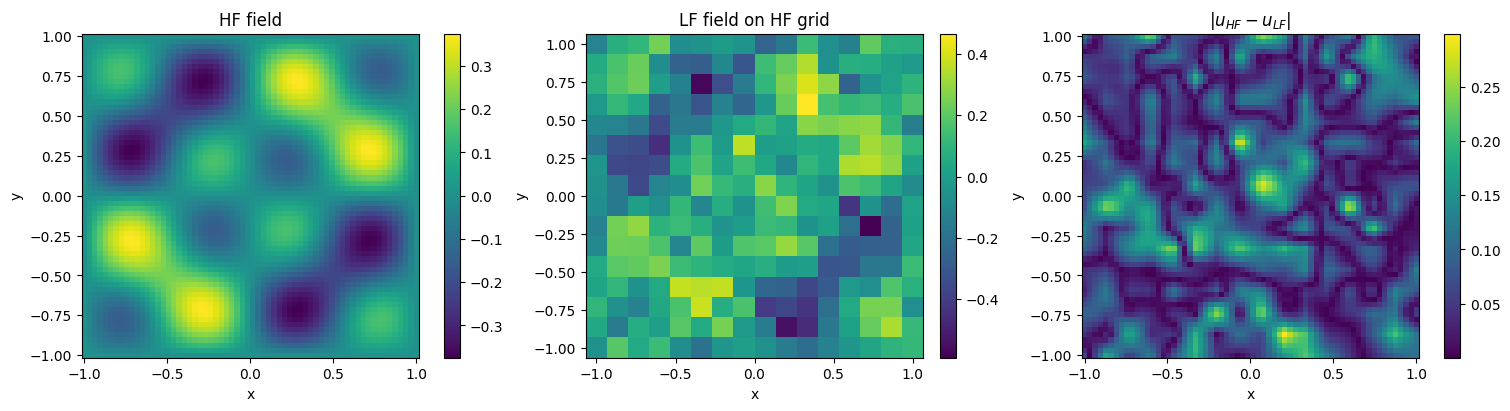

In [3]:
rng = np.random.default_rng(0)
ic = sample_ic(rng=rng)

mf_traj = generate_mf_trajectory(
    ic=ic,
    lf_time=time,
    hf_time=time,
    rng=rng,
)

hf_snapshot = mf_traj.hf_trajectory.states[-1, :, :]
lf_snapshot = mf_traj.lf_trajectory.states[-1, :, :]

x_hf = np.linspace(-1.0, 1.0, hf_snapshot.shape[0])
y_hf = np.linspace(-1.0, 1.0, hf_snapshot.shape[1])
x_lf = np.linspace(-1.0, 1.0, lf_snapshot.shape[0])
y_lf = np.linspace(-1.0, 1.0, lf_snapshot.shape[1])

X_hf, Y_hf = np.meshgrid(x_hf, y_hf, indexing="ij")
X_lf, Y_lf = np.meshgrid(x_lf, y_lf, indexing="ij")

interp = RegularGridInterpolator((x_lf, y_lf), lf_snapshot)
lf_on_hf = interp(np.stack([X_hf.ravel(), Y_hf.ravel()], axis=-1)).reshape(hf_snapshot.shape)
abs_diff = np.abs(hf_snapshot - lf_on_hf)

fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

pcm0 = ax[0].pcolormesh(X_hf, Y_hf, hf_snapshot, shading="auto")
ax[0].set_title("HF field")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
fig.colorbar(pcm0, ax=ax[0])

pcm1 = ax[1].pcolormesh(X_lf, Y_lf, lf_snapshot, shading="auto")
ax[1].set_title("LF field on HF grid")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
fig.colorbar(pcm1, ax=ax[1])

pcm2 = ax[2].pcolormesh(X_hf, Y_hf, abs_diff, shading="auto")
ax[2].set_title(r"$|u_{HF}-u_{LF}|$")
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")
fig.colorbar(pcm2, ax=ax[2])

plt.show()




In [4]:
rng = np.random.default_rng(0)
ic = sample_ic(rng=rng)

mf_traj = generate_mf_trajectory(
    ic=ic,
    lf_time=time,
    hf_time=time,
    rng=rng,
)

hf_states = mf_traj.hf_trajectory.states
lf_states = mf_traj.lf_trajectory.states
hf_time = mf_traj.hf_trajectory.time
lf_time = mf_traj.lf_trajectory.time

x_hf = np.linspace(-1.0, 1.0, hf_states.shape[1])
y_hf = np.linspace(-1.0, 1.0, hf_states.shape[2])
x_lf = np.linspace(-1.0, 1.0, lf_states.shape[1])
y_lf = np.linspace(-1.0, 1.0, lf_states.shape[2])

X_hf, Y_hf = np.meshgrid(x_hf, y_hf, indexing="ij")
X_lf, Y_lf = np.meshgrid(x_lf, y_lf, indexing="ij")
hf_points = np.stack([X_hf.ravel(), Y_hf.ravel()], axis=-1)

# Precompute LF interpolated onto the HF grid
lf_on_hf_states = []
abs_diff_states = []

for k in range(len(hf_time)):
    hf_snapshot = hf_states[k]
    lf_snapshot = lf_states[k]

    interp = RegularGridInterpolator((x_lf, y_lf), lf_snapshot)
    lf_on_hf = interp(hf_points).reshape(hf_snapshot.shape)

    lf_on_hf_states.append(lf_on_hf)
    abs_diff_states.append(np.abs(hf_snapshot - lf_on_hf))

lf_on_hf_states = np.asarray(lf_on_hf_states)
abs_diff_states = np.asarray(abs_diff_states)

# Fixed color limits for stable animation
hf_vmin = min(hf_states.min(), lf_on_hf_states.min())
hf_vmax = max(hf_states.max(), lf_on_hf_states.max())
diff_vmin = 0.0
diff_vmax = abs_diff_states.max()

fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

pcm0 = ax[0].pcolormesh(
    X_hf, Y_hf, hf_states[0],
    shading="auto",
    vmin=hf_vmin, vmax=hf_vmax
)
ax[0].set_title("HF field")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
fig.colorbar(pcm0, ax=ax[0])

pcm1 = ax[1].pcolormesh(
    X_lf, Y_lf, lf_states[0],
    shading="auto",
    vmin=hf_vmin, vmax=hf_vmax
)
ax[1].set_title("LF field on HF grid")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
fig.colorbar(pcm1, ax=ax[1])

pcm2 = ax[2].pcolormesh(
    X_hf, Y_hf, abs_diff_states[0],
    shading="auto",
    vmin=diff_vmin, vmax=diff_vmax
)
ax[2].set_title(r"$|u_{HF}-u_{LF}|$")
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")
fig.colorbar(pcm2, ax=ax[2])

time_text = fig.suptitle(f"t = {hf_time[0]:.3f}")
frame_step = 10
frame_indices = np.arange(0, len(hf_time), frame_step)

def update(frame_idx):
    pcm0.set_array(hf_states[frame_idx].ravel())
    pcm1.set_array(lf_states[frame_idx].ravel())
    pcm2.set_array(abs_diff_states[frame_idx].ravel())
    time_text.set_text(f"t = {hf_time[frame_idx]:.3f}")
    return pcm0, pcm1, pcm2, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=frame_indices,
    interval=80,
    blit=False,
)


plt.close(fig)
HTML(anim.to_jshtml())
